# Amazon Sales Data Analysis

## Task 3 - Deep-Dive Analysis & Interactive Dashboarding

This project focuses on analyzing Amazon ecommerce sales data using Python and Power BI to derive business insights through KPI analysis, customer segmentation, and visualization.

# Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [3]:
df = pd.read_csv("../dataset/cleaned_data.csv")

df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,B09KXVBD7Z,Unknown,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,B099NRCT7B,Unknown,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False


# Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      128975 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            128975 non-null  object 
 15  Amount              128975 non-nul

# KPI Calculations

In [5]:
total_sales = df['Amount'].sum()

total_orders = df['Order ID'].nunique()

total_qty = df['Qty'].sum()

avg_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Total Quantity:", total_qty)
print("Average Order Value:", avg_order_value)

Total Sales: 83648214.91782884
Total Orders: 120378
Total Quantity: 116649
Average Order Value: 694.8795869496822


# Customer Segmentation Analysis

In [6]:
def segment_customer(amount):
    if amount > 1000:
        return "High Value"
    elif amount > 500:
        return "Medium Value"
    else:
        return "Low Value"

df['Customer Segment'] = df['Amount'].apply(segment_customer)

df[['Amount', 'Customer Segment']].head()

,Amount,Customer Segment
0,647.62,Medium Value
1,406.00,Low Value
2,329.00,Low Value
3,753.33,Medium Value
4,574.00,Medium Value


# Sales by Category Visualization

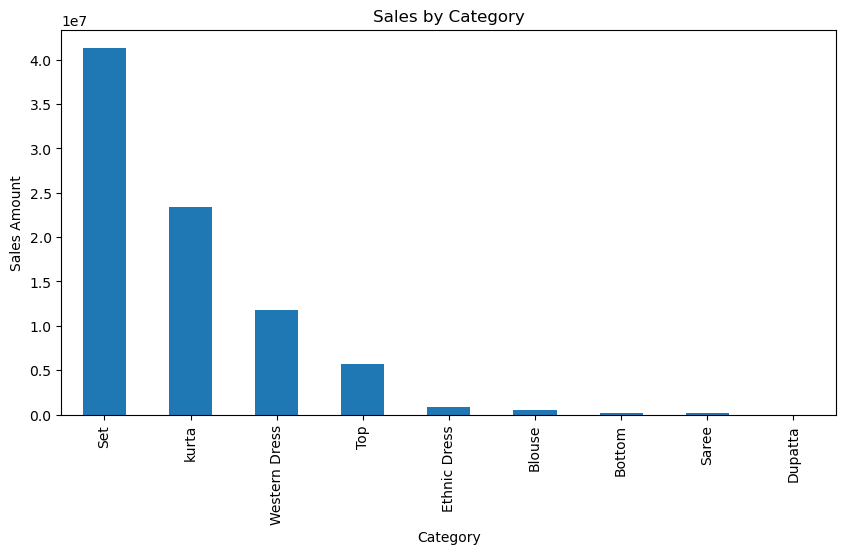

In [7]:
category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

category_sales.plot(kind='bar')

plt.title("Sales by Category")

plt.xlabel("Category")

plt.ylabel("Sales Amount")

plt.show()

# Monthly Sales Trend

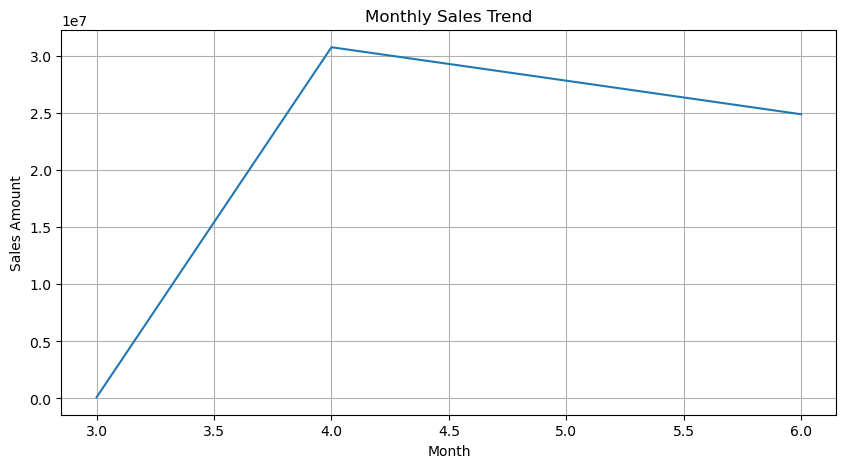

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = df.groupby(df['Date'].dt.month)['Amount'].sum()

monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales Amount")

plt.grid(True)

plt.show()

# Customer Segment Distribution

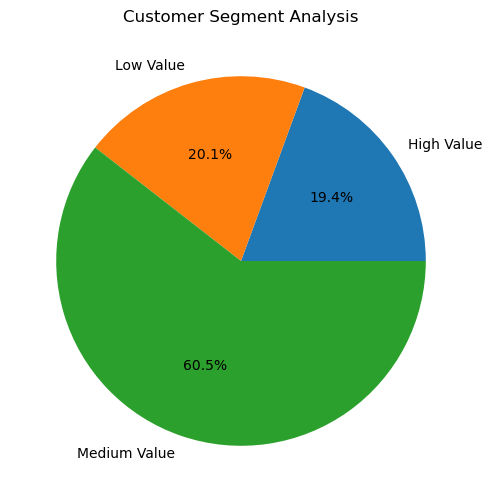

In [9]:
segment_sales = df.groupby('Customer Segment')['Amount'].sum()

segment_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))

plt.title("Customer Segment Analysis")

plt.ylabel("")

plt.show()

# Key Insights

- Sets and Kurtas generated the highest sales.
- High-value customers contributed significant revenue.
- Monthly sales trends showed fluctuations across different periods.
- Interactive dashboarding in Power BI improved data exploration.